# Final project

## Setup

- Import the packages you'll need
- Import your OpenAI API key: You can do this by running \``export OPENAI_API_KEY="your API key"`\` in your terminal.
- Set a directory to save images to

In [1]:
import os
import openai

from dotenv import load_dotenv
load_dotenv('.env')

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [2]:
# imports
from openai import OpenAI  # OpenAI Python library to make API calls
import requests  # used to download images
import os  # used to access filepaths
from PIL import Image  # used to print and edit images

In [3]:

# initialize OpenAI client
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", OPENAI_API_KEY))

In [4]:
# set a directory to save DALL·E images to
image_dir_name = "images"
image_dir = os.path.join(os.curdir, image_dir_name)

# create the directory if it doesn't yet exist
if not os.path.isdir(image_dir):
    os.mkdir(image_dir)

# print the directory to save to
print(f"{image_dir=}")


image_dir='./images'


## Generations

The generation API endpoint creates an image based on a text prompt. [API Reference](https://platform.openai.com/docs/api-reference/images/create)

**Required inputs:**
- `prompt` (str): A text description of the desired image(s). The maximum length is 1000 characters for dall-e-2 and 4000 characters for dall-e-3.

**Optional inputs:**
- `model` (str): The model to use for image generation. Defaults to dall-e-2
- `n` (int): The number of images to generate. Must be between 1 and 10. Defaults to 1.
- `quality` (str): The quality of the image that will be generated. hd creates images with finer details and greater consistency across the image. This param is only supported for dall-e-3.
- `response_format` (str): The format in which the generated images are returned. Must be one of "url" or "b64_json". Defaults to "url".
- `size` (str): The size of the generated images. Must be one of 256x256, 512x512, or 1024x1024 for dall-e-2. Must be one of 1024x1024, 1792x1024, or 1024x1792 for dall-e-3 models. Defaults to "1024x1024".
- `style`(str | null): The style of the generated images. Must be one of vivid or natural. Vivid causes the model to lean towards generating hyper-real and dramatic images. Natural causes the model to produce more natural, less hyper-real looking images. This param is only supported for dall-e-3.
- `user` (str): A unique identifier representing your end-user, which will help OpenAI to monitor and detect abuse. [Learn more.](https://beta.openai.com/docs/usage-policies/end-user-ids)

In [5]:
with open("prompt.txt", mode='r') as text:
    prompt = text.read()
print(prompt)

A product photo of a Nike sneaker designed for American college students. The shoe should have a leather construction and express a general gen-Z aesthetic, featuring bold colors and the classic recognizeable Nike logo on the side. The image should show the shoe from a side view on an urban American college campus.



In [8]:
# create images

# call the OpenAI API
generation_responses = [client.images.generate(
    model = "dall-e-3",
    prompt=prompt,
    n=1,
    size="1024x1024",
    response_format="url",
) for _ in range(3)]

# print response
display(generation_responses)

[ImagesResponse(created=1764637170, data=[Image(b64_json=None, revised_prompt='A product photo of an athletic sneaker designed for college students. This footwear boasts a leather construction complimented by a vibrant Gen-Z aesthetic, featuring bold colors. The iconic brand symbol is visible on the side. The perspective provides a side view of the shoe, capturing its design details. It is placed in an urban American college campus backdrop.', url='https://oaidalleapiprodscus.blob.core.windows.net/private/org-xbAzpnXxoEeGxjmoYmGdCFwU/user-YpeonBJU3VFRzsfyP06Q8BAm/img-AHlzoJcH0OCJ4FnKyHgus1uG.png?st=2025-12-01T23%3A59%3A29Z&se=2025-12-02T01%3A59%3A29Z&sp=r&sv=2024-08-04&sr=b&rscd=inline&rsct=image/png&skoid=7daae675-7b42-4e2e-ab4c-8d8419a28d99&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2025-12-02T00%3A59%3A29Z&ske=2025-12-03T00%3A59%3A29Z&sks=b&skv=2024-08-04&sig=GmUsMWqZsO8pl3BuHfZ%2BhP/jWZHKygC8dg5omWg0CCA%3D')], usage=None),
 ImagesResponse(created=1764637180, data=[Image(b64_jso

In [12]:
# save the image
generated_image_filepaths = []
for i, response in enumerate(generation_responses):
    generated_image_name = f"generated_image{i}.png"  # any name you like; the filetype should be .png
    generated_image_filepath = os.path.join(image_dir, generated_image_name)
    generated_image_filepaths.append(generated_image_filepath)

    generated_image_url = response.data[0].url  # extract image URL from response
    generated_image = requests.get(generated_image_url).content  # download the image
    with open(generated_image_filepath, "wb") as image_file:
        image_file.write(generated_image)  # write the image to the file

./images/generated_image0.png


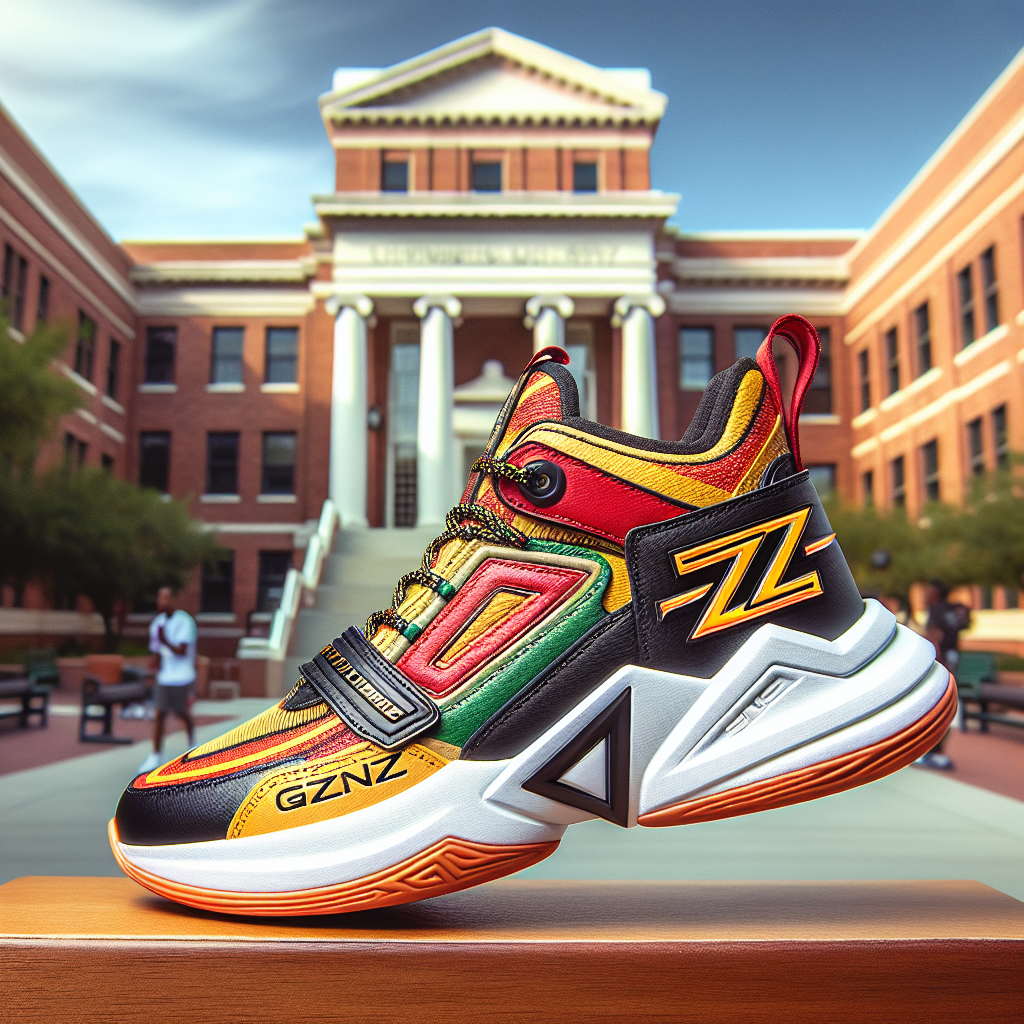

./images/generated_image1.png


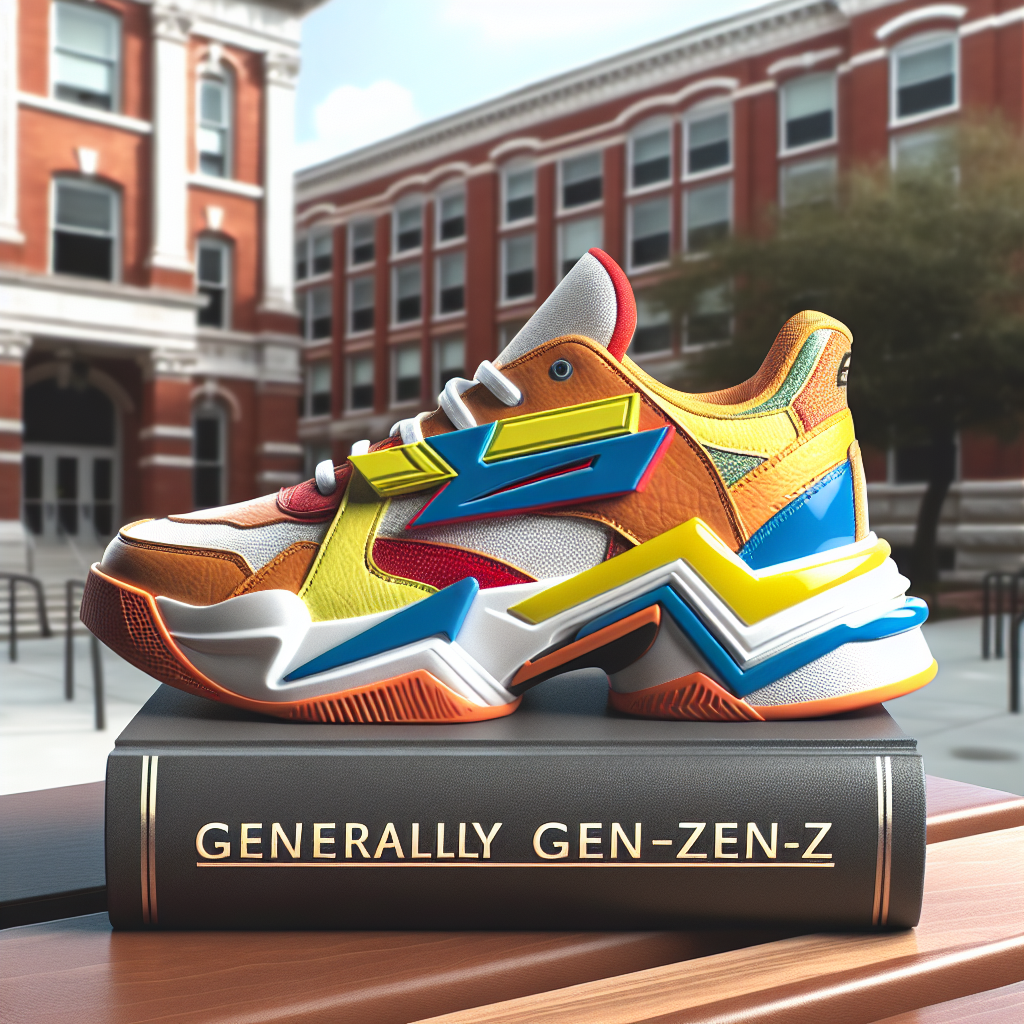

./images/generated_image2.png


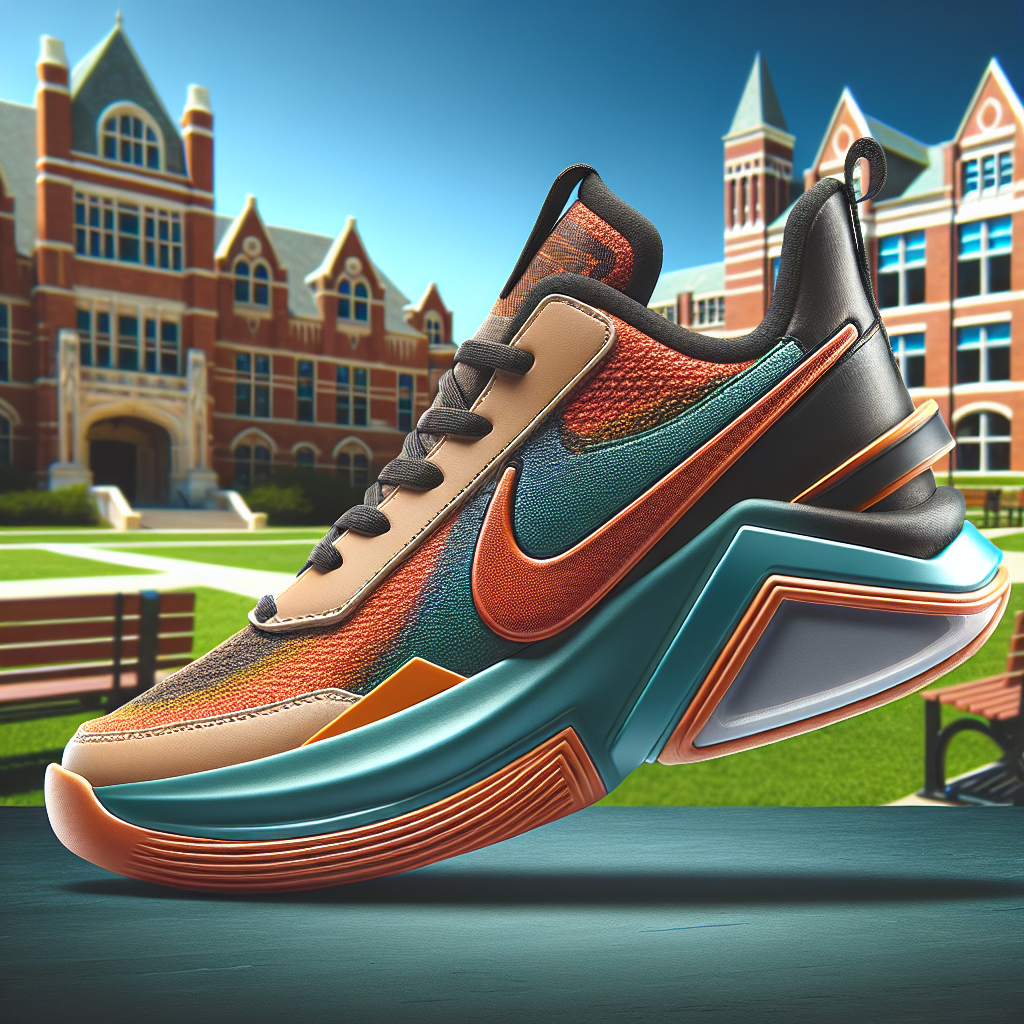

In [13]:
# print the image
for i, generated_image_filepath in enumerate(generated_image_filepaths):
    print(generated_image_filepath)
    with Image.open(generated_image_filepath) as image:
        display(image)


# evaluation
- instead of looking appealing to college students, I think they're too flashy; I'd imagine them being more appealing to younger children (~6-14 years old)
- only one of the shoes has the nike brand on it, the other two do not
- all three correctly have a college campus setting in the background
- I think all three shoes have leather? the third image has less than the other two but arguably still does have leather
- all three images show the shoes in the correct angle (from the side)

# Tweak the prompt

## old prompt

In [15]:
display(prompt)

'A product photo of a Nike sneaker designed for American college students. The shoe should have a leather construction and express a general gen-Z aesthetic, featuring bold colors and the classic recognizeable Nike logo on the side. The image should show the shoe from a side view on an urban American college campus.\n'

## new prompt

In [ ]:
with open("prompt_revised.txt", mode='r') as text:
    prompt = text.read()
print(prompt)